In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
df = pd.read_excel("../data/raw/online_retail_II.xlsx")

In [153]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

df.head()

Shape: (525461, 8)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(6865)

In [9]:
df.nunique()

Invoice        28816
StockCode       4632
Description     4681
Quantity         825
InvoiceDate    25296
Price           1606
Customer ID     4383
Country           40
dtype: int64

In [10]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [11]:
df.sample(5, random_state=42)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
391453,527050,20750,RED RETROSPOT MINI CASES,6,2010-10-14 12:54:00,7.95,17717.0,United Kingdom
440086,531382,82583,HOT BATHS METAL SIGN,3,2010-11-07 16:29:00,2.10,16549.0,United Kingdom
369036,525059,22951,72 CAKE CASES DOLLY GIRL DESIGN,48,2010-10-03 14:08:00,0.55,15978.0,United Kingdom
232578,511928,21915,RED HARMONICA IN BOX,12,2010-06-11 11:45:00,1.25,15141.0,United Kingdom
41357,492792,22311,OFFICE MUG WARMER BLACK+SILVER,12,2009-12-20 10:08:00,4.95,17243.0,United Kingdom


In [12]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [13]:
df = df.drop_duplicates()
print("Shape after duplicates:", df.shape)

Shape after duplicates: (518596, 8)


In [14]:
df["Customer ID"].isnull().sum()

np.int64(107833)

In [15]:
df = df.dropna(subset=["Customer ID"])
print("Shape:", df.shape)



Shape: (410763, 8)


In [16]:
df["Description"].isnull().sum()

np.int64(0)

In [17]:
df["Description"] = df["Description"].fillna("Unknown")
print("Missing Description:", df["Description"].isnull().sum())

Missing Description: 0


In [18]:

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
print(df["InvoiceDate"].dtype)


datetime64[us]


In [19]:
df["Invoice"].astype(str).str.startswith("C").sum()

np.int64(9816)

In [20]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]
print("Shape:", df.shape)

Shape: (400947, 8)


In [21]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Price <= 0:", (df["Price"] <= 0).sum())

Quantity <= 0: 0
Price <= 0: 31


In [22]:
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
print("Final shape after validity check:", df.shape)

Final shape after validity check: (400916, 8)


In [23]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400916 non-null  object        
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[us]
 5   Price        400916 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      400916 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.7+ MB
None


In [24]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')


In [25]:
print(df.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [26]:
print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


In [27]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [28]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [29]:
print(df["InvoiceDate"].dtype)

datetime64[us]


In [30]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(df["InvoiceDate"].dtype)

datetime64[us]


In [31]:
print("First transaction:", df["InvoiceDate"].min())
print("Last transaction:", df["InvoiceDate"].max())

First transaction: 2009-12-01 07:45:00
Last transaction: 2010-12-09 20:01:00


In [32]:
print("Unique customers:", df["Customer ID"].nunique())

Unique customers: 4312


In [33]:
print("Missing Customer IDs:", df["Customer ID"].isnull().sum())

Missing Customer IDs: 0


In [34]:
df[["Invoice", "Customer ID", "InvoiceDate", "Quantity", "Price"]].head()

,Invoice,Customer ID,InvoiceDate,Quantity,Price
0,489434,13085.0,2009-12-01 07:45:00,12,6.95
1,489434,13085.0,2009-12-01 07:45:00,12,6.75
2,489434,13085.0,2009-12-01 07:45:00,12,6.75
3,489434,13085.0,2009-12-01 07:45:00,48,2.10
4,489434,13085.0,2009-12-01 07:45:00,24,1.25


In [35]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [36]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [37]:
df.shape

(400916, 9)

In [38]:
df.to_csv("../data/processed/cleaned_retail_data.csv", index=False)

In [39]:
print("Total Sales:", df["TotalAmount"].sum())

Total Sales: 8798233.743999999


In [40]:
customer_summary = df.groupby("Customer ID").agg(
    Total_Spending=("TotalAmount", "sum"),
    Total_Transactions=("Invoice", "nunique"),
    Total_Products=("Quantity", "sum")
).reset_index()

customer_summary.head()

,Customer ID,Total_Spending,Total_Transactions,Total_Products
0,12346.0,372.86,11,70
1,12347.0,1323.32,2,828
2,12348.0,222.16,1,373
3,12349.0,2671.14,3,993
4,12351.0,300.93,1,261


In [41]:
print("Number of customers:", customer_summary.shape[0])
print("Number of features:", customer_summary.shape[1])

Number of customers: 4312
Number of features: 4


In [42]:
customer_summary["Avg_Transaction_Value"] = (
    customer_summary["Total_Spending"]
    / customer_summary["Total_Transactions"]
)

customer_summary.head()

,Customer ID,Total_Spending,Total_Transactions,Total_Products,Avg_Transaction_Value
0,12346.0,372.86,11,70,33.896364
1,12347.0,1323.32,2,828,661.660000
2,12348.0,222.16,1,373,222.160000
3,12349.0,2671.14,3,993,890.380000
4,12351.0,300.93,1,261,300.930000


In [43]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2010-12-10 20:01:00


In [44]:
customer_summary.describe()

,Customer ID,Total_Spending,Total_Transactions,Total_Products,Avg_Transaction_Value
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,4.455705,1280.050557,376.373364
std,1701.200176,8911.755977,8.170213,6457.926351,492.357455
min,12346.000000,2.950000,1.000000,1.000000,2.950000
25%,13882.500000,307.187500,1.000000,156.000000,179.490000
50%,15350.500000,701.615000,2.000000,380.000000,285.048333
75%,16834.250000,1714.932500,5.000000,992.000000,421.483750
max,18287.000000,349164.350000,205.000000,220600.000000,11880.840000


In [45]:
recency = df.groupby("Customer ID")["InvoiceDate"].max().reset_index()

recency["Recency"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

recency = recency[["Customer ID", "Recency"]]

recency.head()


,Customer ID,Recency
0,12346.0,165
1,12347.0,3
2,12348.0,74
3,12349.0,43
4,12351.0,11


In [46]:
frequency = df.groupby("Customer ID")["Invoice"].nunique().reset_index()

frequency.columns = ["Customer ID", "Frequency"]

frequency.head()

,Customer ID,Frequency
0,12346.0,11
1,12347.0,2
2,12348.0,1
3,12349.0,3
4,12351.0,1


In [47]:
monetary = df.groupby("Customer ID")["TotalAmount"].sum().reset_index()

monetary.columns = ["Customer ID", "Monetary"]

monetary.head()

,Customer ID,Monetary
0,12346.0,372.86
1,12347.0,1323.32
2,12348.0,222.16
3,12349.0,2671.14
4,12351.0,300.93


In [48]:
rfm = recency.merge(frequency, on="Customer ID")

rfm = rfm.merge(monetary, on="Customer ID")

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [49]:
print(rfm.shape)

rfm.describe()

(4312, 4)


,Customer ID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2040.406712
std,1701.200176,96.860633,8.170213,8911.755977
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.187500
50%,15350.500000,53.000000,2.000000,701.615000
75%,16834.250000,136.000000,5.000000,1714.932500
max,18287.000000,374.000000,205.000000,349164.350000


In [50]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [51]:
print(rfm.isnull().sum())

Customer ID    0
Recency        0
Frequency      0
Monetary       0
dtype: int64


In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
rfm_features = rfm[
    ["Recency", "Frequency", "Monetary"]
]

rfm_features.head()

,Recency,Frequency,Monetary
0,165,11,372.86
1,3,2,1323.32
2,74,1,222.16
3,43,3,2671.14
4,11,1,300.93


In [54]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

print(rfm_scaled[:5])

[[ 0.76229851  0.80108727 -0.18713934]
 [-0.91040156 -0.3006029  -0.08047459]
 [-0.17730462 -0.42301292 -0.20405155]
 [-0.4973892  -0.17819288  0.07078363]
 [-0.82779909 -0.42301292 -0.19521163]]


In [55]:
print("Original RFM shape:", rfm_features.shape)
print("Scaled RFM shape:", rfm_scaled.shape)

Original RFM shape: (4312, 3)
Scaled RFM shape: (4312, 3)


In [56]:
from sklearn.cluster import KMeans

In [57]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

In [58]:
print(inertia)

[12936.000000000002, 8728.911702720845, 5160.291654286159, 3587.352269496303, 2740.115385952543, 2236.0619397294927, 1820.1070745770885, 1560.0993818863888, 1401.9474399077822, 1251.1456230518795]


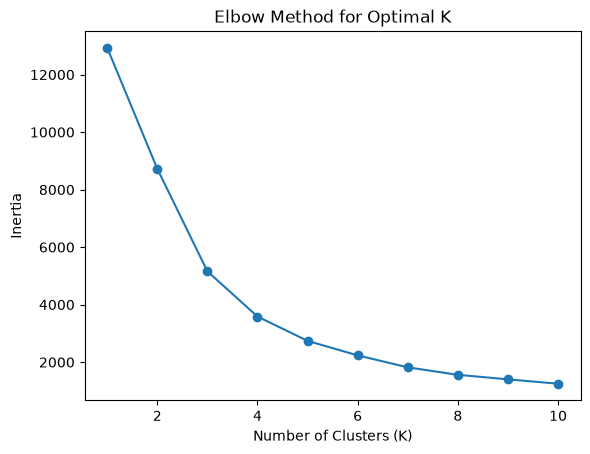

In [59]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.savefig("../visuals/Elbow Method for Optimal K.png", bbox_inches="tight")
plt.show()

In [60]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,165,11,372.86,1
1,12347.0,3,2,1323.32,0
2,12348.0,74,1,222.16,0
3,12349.0,43,3,2671.14,0
4,12351.0,11,1,300.93,0


In [61]:
print(rfm["Cluster"].value_counts().sort_index())

Cluster
0    3204
1    1047
2       5
3      56
Name: count, dtype: int64


In [62]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean")
).round(2)

cluster_summary

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,3204,43.03,4.46,1710.65
1,1047,242.98,1.66,593.54
2,5,5.60,113.60,215535.00
3,56,14.91,47.02,28896.42


In [63]:
cluster_summary.sort_values(
    "Monetary",
    ascending=False
).round(2)

,Customers,Recency,Frequency,Monetary
Cluster,,,,
2,5,5.60,113.60,215535.00
3,56,14.91,47.02,28896.42
0,3204,43.03,4.46,1710.65
1,1047,242.98,1.66,593.54


In [64]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=["Recency", "Frequency", "Monetary"]
)

cluster_centers.round(2)

,Recency,Frequency,Monetary
0,43.03,4.46,1710.65
1,242.98,1.66,593.54
2,5.60,113.60,215535.00
3,14.91,47.02,28896.42


In [65]:
rfm["Segment"] = rfm["Cluster"].map({
    0: "Segment 0",
    1: "Segment 1",
    2: "Segment 2",
    3: "Segment 3"
})

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,165,11,372.86,1,Segment 1
1,12347.0,3,2,1323.32,0,Segment 0
2,12348.0,74,1,222.16,0,Segment 0
3,12349.0,43,3,2671.14,0,Segment 0
4,12351.0,11,1,300.93,0,Segment 0


In [66]:
rfm["Segment"].value_counts()

Segment
Segment 0    3204
Segment 1    1047
Segment 3      56
Segment 2       5
Name: count, dtype: int64

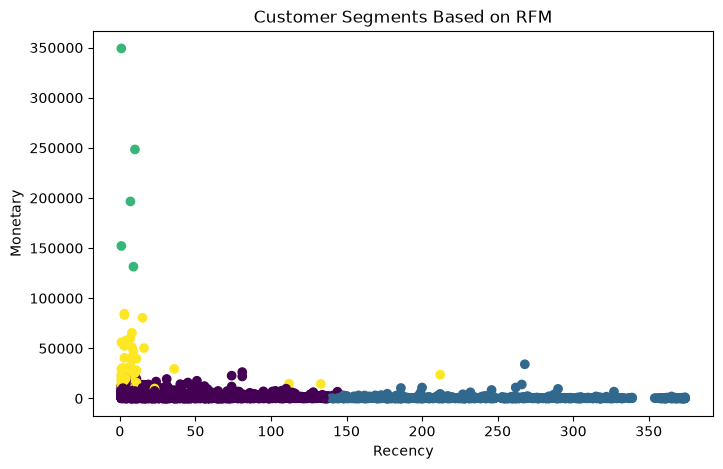

In [67]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segments Based on RFM")
plt.savefig("../visuals/Customer Segments Based on RFM.png", bbox_inches="tight")
plt.show()

In [68]:
cluster_summary

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,3204,43.03,4.46,1710.65
1,1047,242.98,1.66,593.54
2,5,5.60,113.60,215535.00
3,56,14.91,47.02,28896.42


In [69]:
segment_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "VIP Customers",
    3: "Loyal High-Value Customers"
}

In [70]:
rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,165,11,372.86,1,At-Risk Customers
1,12347.0,3,2,1323.32,0,Regular Customers
2,12348.0,74,1,222.16,0,Regular Customers
3,12349.0,43,3,2671.14,0,Regular Customers
4,12351.0,11,1,300.93,0,Regular Customers


In [71]:
rfm["Segment"].value_counts()

Segment
Regular Customers             3204
At-Risk Customers             1047
Loyal High-Value Customers      56
VIP Customers                    5
Name: count, dtype: int64

In [72]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk Customers,1047,242.98,1.66,593.54
Loyal High-Value Customers,56,14.91,47.02,28896.42
Regular Customers,3204,43.03,4.46,1710.65
VIP Customers,5,5.60,113.60,215535.00


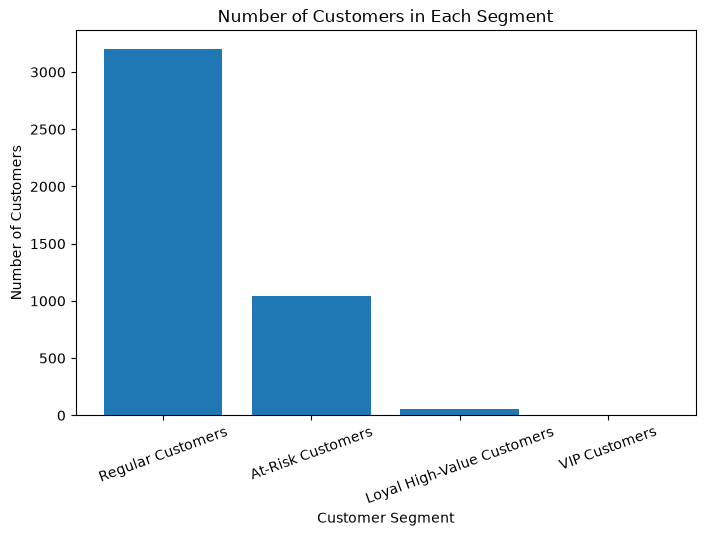

In [73]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Segment")

plt.xticks(rotation=20)
plt.savefig("../visuals/Number of Customers in Each Segment.png", bbox_inches="tight")
plt.show()

In [74]:
print("Final RFM dataset shape:", rfm.shape)

rfm.head()

Final RFM dataset shape: (4312, 6)


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,165,11,372.86,1,At-Risk Customers
1,12347.0,3,2,1323.32,0,Regular Customers
2,12348.0,74,1,222.16,0,Regular Customers
3,12349.0,43,3,2671.14,0,Regular Customers
4,12351.0,11,1,300.93,0,Regular Customers


In [75]:
print("Start date:", df["InvoiceDate"].min())
print("End date:", df["InvoiceDate"].max())

Start date: 2009-12-01 07:45:00
End date: 2010-12-09 20:01:00


In [76]:
max_date = df["InvoiceDate"].max()

cutoff_date = max_date - pd.Timedelta(days=90)

print("Prediction cutoff date:", cutoff_date)

Prediction cutoff date: 2010-09-10 20:01:00


In [77]:
historical_df = df[
    df["InvoiceDate"] <= cutoff_date
].copy()

future_df = df[
    df["InvoiceDate"] > cutoff_date
].copy()

print("Historical data shape:", historical_df.shape)
print("Future data shape:", future_df.shape)

Historical data shape: (253543, 9)
Future data shape: (147373, 9)


In [78]:
print("Historical period:")
print(historical_df["InvoiceDate"].min())
print(historical_df["InvoiceDate"].max())

print("\nFuture 90-day period:")
print(future_df["InvoiceDate"].min())
print(future_df["InvoiceDate"].max())

Historical period:
2009-12-01 07:45:00
2010-09-10 17:19:00

Future 90-day period:
2010-09-12 10:18:00
2010-12-09 20:01:00


In [79]:
future_customers = future_df["Customer ID"].unique()

print(
    "Customers who purchased in the next 90 days:",
    len(future_customers)
)

Customers who purchased in the next 90 days: 2877


In [80]:
historical_customers = historical_df["Customer ID"].unique()

print(
    "Historical customers:",
    len(historical_customers)
)

Historical customers: 3377


In [81]:
future_customer_set = set(future_customers)

print("Future customer set created")

Future customer set created


In [82]:
target_df = pd.DataFrame({
    "Customer ID": historical_customers
})

target_df.head()

,Customer ID
0,13085.0
1,13078.0
2,15362.0
3,18102.0
4,12682.0


In [83]:
target_df["Repeat_Purchase_90D"] = target_df["Customer ID"].isin(
    future_customer_set
).astype(int)

target_df.head()

,Customer ID,Repeat_Purchase_90D
0,13085.0,0
1,13078.0,1
2,15362.0,1
3,18102.0,1
4,12682.0,1


In [84]:
print(
    target_df["Repeat_Purchase_90D"]
    .value_counts()
)

Repeat_Purchase_90D
1    1942
0    1435
Name: count, dtype: int64


In [85]:
print(
    target_df["Repeat_Purchase_90D"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Repeat_Purchase_90D
1    57.51
0    42.49
Name: proportion, dtype: float64


In [86]:
print("Target dataset shape:", target_df.shape)

target_df.head()

Target dataset shape: (3377, 2)


,Customer ID,Repeat_Purchase_90D
0,13085.0,0
1,13078.0,1
2,15362.0,1
3,18102.0,1
4,12682.0,1


In [87]:
historical_df["TotalAmount"] = (
    historical_df["Quantity"] * historical_df["Price"]
)

historical_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [88]:
historical_reference_date = (
    historical_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print(historical_reference_date)

2010-09-11 17:19:00


In [89]:
historical_recency = (
    historical_df
    .groupby("Customer ID")["InvoiceDate"]
    .max()
    .reset_index()
)

historical_recency["Recency"] = (
    historical_reference_date
    - historical_recency["InvoiceDate"]
).dt.days

historical_recency = historical_recency[
    ["Customer ID", "Recency"]
]

historical_recency.head()

,Customer ID,Recency
0,12346.0,75
1,12349.0,116
2,12355.0,113
3,12358.0,96
4,12359.0,81


In [90]:
historical_frequency = (
    historical_df
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index()
)

historical_frequency.columns = [
    "Customer ID",
    "Frequency"
]

historical_frequency.head()

,Customer ID,Frequency
0,12346.0,11
1,12349.0,2
2,12355.0,1
3,12358.0,2
4,12359.0,5


In [91]:
historical_monetary = (
    historical_df
    .groupby("Customer ID")["TotalAmount"]
    .sum()
    .reset_index()
)

historical_monetary.columns = [
    "Customer ID",
    "Monetary"
]

historical_monetary.head()

,Customer ID,Monetary
0,12346.0,372.86
1,12349.0,1268.52
2,12355.0,488.21
3,12358.0,1697.93
4,12359.0,2012.03


In [92]:
ml_features = (
    historical_recency
    .merge(
        historical_frequency,
        on="Customer ID"
    )
    .merge(
        historical_monetary,
        on="Customer ID"
    )
)

print("ML feature dataset shape:", ml_features.shape)

ml_features.head()

ML feature dataset shape: (3377, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346.0,75,11,372.86
1,12349.0,116,2,1268.52
2,12355.0,113,1,488.21
3,12358.0,96,2,1697.93
4,12359.0,81,5,2012.03


In [93]:
ml_df = ml_features.merge(
    target_df,
    on="Customer ID"
)

print("Final ML dataset shape:", ml_df.shape)

ml_df.head()

Final ML dataset shape: (3377, 5)


,Customer ID,Recency,Frequency,Monetary,Repeat_Purchase_90D
0,12346.0,75,11,372.86,0
1,12349.0,116,2,1268.52,1
2,12355.0,113,1,488.21,0
3,12358.0,96,2,1697.93,1
4,12359.0,81,5,2012.03,1


In [94]:
print(ml_df.isnull().sum())

Customer ID            0
Recency                0
Frequency              0
Monetary               0
Repeat_Purchase_90D    0
dtype: int64


In [95]:
print(ml_df["Repeat_Purchase_90D"].value_counts())

Repeat_Purchase_90D
1    1942
0    1435
Name: count, dtype: int64


In [96]:
print(
    ml_df["Repeat_Purchase_90D"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Repeat_Purchase_90D
1    57.51
0    42.49
Name: proportion, dtype: float64


In [97]:
ml_df[
    ["Recency", "Frequency", "Monetary"]
].describe()

,Recency,Frequency,Monetary
count,3377.000000,3377.000000,3377.000000
mean,94.043826,3.699437,1677.111158
std,77.686851,6.237545,7299.197545
min,1.000000,1.000000,2.950000
25%,27.000000,1.000000,270.920000
50%,75.000000,2.000000,597.230000
75%,143.000000,4.000000,1423.050000
max,284.000000,122.000000,269041.670000


In [98]:
X = ml_df[
    ["Recency", "Frequency", "Monetary"]
]

y = ml_df["Repeat_Purchase_90D"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3377, 3)
y shape: (3377,)


In [99]:
X = ml_df[
    ["Recency", "Frequency", "Monetary"]
].copy()

y = ml_df["Repeat_Purchase_90D"].copy()

print(X.head())
print(y.value_counts())

   Recency  Frequency  Monetary
0       75         11    372.86
1      116          2   1268.52
2      113          1    488.21
3       96          2   1697.93
4       81          5   2012.03
Repeat_Purchase_90D
1    1942
0    1435
Name: count, dtype: int64


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2701, 3)
Testing data: (676, 3)


In [101]:
from sklearn.preprocessing import StandardScaler

scaler_ml = StandardScaler()

X_train_scaled = scaler_ml.fit_transform(X_train)

X_test_scaled = scaler_ml.transform(X_test)

print("Scaling completed")

Scaling completed


In [102]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [103]:
y_pred_log = log_model.predict(
    X_test_scaled
)

y_pred_log[:10]

array([0, 1, 0, 1, 1, 1, 0, 1, 0, 0])

In [104]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

print(
    "Logistic Regression Accuracy:",
    round(log_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 65.83 %


In [105]:
from sklearn.neighbors import KNeighborsClassifier

In [106]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

print("KNN model trained successfully")

KNN model trained successfully


In [107]:
y_pred_knn = knn_model.predict(
    X_test_scaled
)

print(y_pred_knn[:10])

[0 0 1 1 1 1 0 1 0 0]


In [108]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print(
    "KNN Accuracy:",
    round(knn_accuracy * 100, 2),
    "%"
)

KNN Accuracy: 60.06 %


In [109]:
k_scores = {}

for k in range(1, 21):
    knn = KNeighborsClassifier(
        n_neighbors=k
    )
    
    knn.fit(X_train_scaled, y_train)
    
    score = knn.score(
        X_test_scaled,
        y_test
    )
    
    k_scores[k] = score

print(k_scores)

{1: 0.5784023668639053, 2: 0.5710059171597633, 3: 0.606508875739645, 4: 0.6005917159763313, 5: 0.6005917159763313, 6: 0.6124260355029586, 7: 0.5976331360946746, 8: 0.6109467455621301, 9: 0.591715976331361, 10: 0.6005917159763313, 11: 0.5902366863905325, 12: 0.606508875739645, 13: 0.6035502958579881, 14: 0.6153846153846154, 15: 0.6183431952662722, 16: 0.6227810650887574, 17: 0.6242603550295858, 18: 0.6331360946745562, 19: 0.6316568047337278, 20: 0.6331360946745562}


In [110]:
best_k = max(
    k_scores,
    key=k_scores.get
)

best_score = k_scores[best_k]

print("Best K:", best_k)
print(
    "Best KNN Accuracy:",
    round(best_score * 100, 2),
    "%"
)

Best K: 18
Best KNN Accuracy: 63.31 %


In [111]:
from sklearn.tree import DecisionTreeClassifier

In [112]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [113]:
y_pred_tree = tree_model.predict(X_test)

print(y_pred_tree[:10])

[0 0 1 1 0 0 0 0 0 0]


In [114]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print(
    "Decision Tree Accuracy:",
    round(tree_accuracy * 100, 2),
    "%"
)

Decision Tree Accuracy: 62.28 %


In [115]:
tree_model_depth = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model_depth.fit(X_train, y_train)

y_pred_tree_depth = tree_model_depth.predict(X_test)

tree_depth_accuracy = accuracy_score(
    y_test,
    y_pred_tree_depth
)

print(
    "Decision Tree (max_depth=5) Accuracy:",
    round(tree_depth_accuracy * 100, 2),
    "%"
)

Decision Tree (max_depth=5) Accuracy: 65.83 %


In [116]:
print("Default Decision Tree:",
      round(tree_accuracy * 100, 2), "%")

print("Decision Tree max_depth=5:",
      round(tree_depth_accuracy * 100, 2), "%")

Default Decision Tree: 62.28 %
Decision Tree max_depth=5: 65.83 %


In [117]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [118]:
print("Logistic Regression")

print("Precision:", round(
    precision_score(y_test, y_pred_log), 3
))

print("Recall:", round(
    recall_score(y_test, y_pred_log), 3
))

print("F1 Score:", round(
    f1_score(y_test, y_pred_log), 3
))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression
Precision: 0.698
Recall: 0.717
F1 Score: 0.707

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.58      0.59       287
           1       0.70      0.72      0.71       389

    accuracy                           0.66       676
   macro avg       0.65      0.65      0.65       676
weighted avg       0.66      0.66      0.66       676



In [119]:
print("KNN")

print("Precision:", round(
    precision_score(y_test, y_pred_knn), 3
))

print("Recall:", round(
    recall_score(y_test, y_pred_knn), 3
))

print("F1 Score:", round(
    f1_score(y_test, y_pred_knn), 3
))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN
Precision: 0.647
Recall: 0.674
F1 Score: 0.66

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.50      0.52       287
           1       0.65      0.67      0.66       389

    accuracy                           0.60       676
   macro avg       0.59      0.59      0.59       676
weighted avg       0.60      0.60      0.60       676



In [120]:
print("Decision Tree")

print("Precision:", round(
    precision_score(y_test, y_pred_tree_depth), 3
))

print("Recall:", round(
    recall_score(y_test, y_pred_tree_depth), 3
))

print("F1 Score:", round(
    f1_score(y_test, y_pred_tree_depth), 3
))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tree_depth))

Decision Tree
Precision: 0.699
Recall: 0.712
F1 Score: 0.706

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.59      0.59       287
           1       0.70      0.71      0.71       389

    accuracy                           0.66       676
   macro avg       0.65      0.65      0.65       676
weighted avg       0.66      0.66      0.66       676



In [121]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree (Depth=5)"
    ],
    "Accuracy": [
        log_accuracy,
        knn_accuracy,
        tree_depth_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_tree_depth)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_tree_depth)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_tree_depth)
    ]
})

model_results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.658,0.698,0.717,0.707
1,KNN,0.601,0.647,0.674,0.660
2,Decision Tree (Depth=5),0.658,0.699,0.712,0.706


In [122]:
best_model = model_results.sort_values(
    "F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.658284,0.697500,0.717224,0.707224
2,Decision Tree (Depth=5),0.658284,0.699495,0.712082,0.705732
1,KNN,0.600592,0.646914,0.673522,0.659950


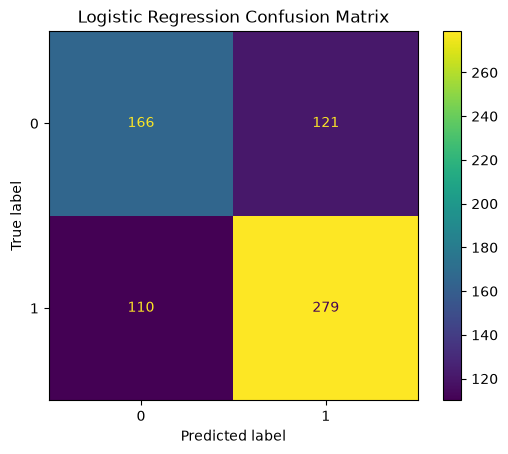

In [123]:
cm_log = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(
    confusion_matrix=cm_log
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.savefig("../visuals/Logistic_Regression_Confusion_Matrix.png", bbox_inches="tight")
plt.show()

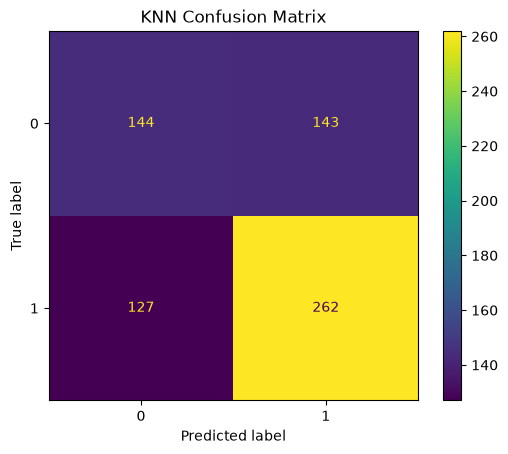

In [124]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(
    confusion_matrix=cm_knn
).plot()

plt.title("KNN Confusion Matrix")
plt.savefig("../visuals/KNN_Confusion_Matrix.png", bbox_inches="tight")
plt.show()

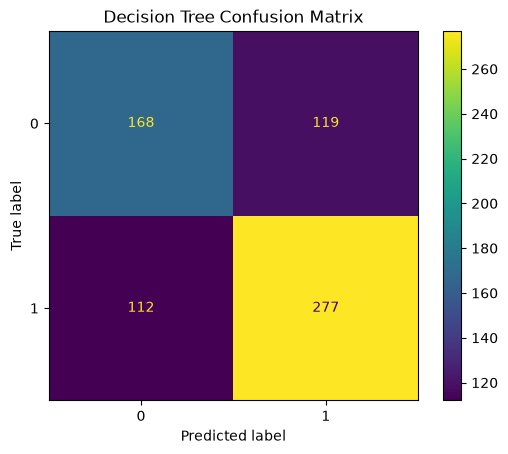

In [125]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree_depth
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree
).plot()

plt.title("Decision Tree Confusion Matrix")
plt.savefig("../visuals/Decision_Tree_Confusion_Matrix.png", bbox_inches="tight")
plt.show()

In [126]:
model_results.sort_values(
    "F1 Score",
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.658,0.698,0.717,0.707
2,Decision Tree (Depth=5),0.658,0.699,0.712,0.706
1,KNN,0.601,0.647,0.674,0.660


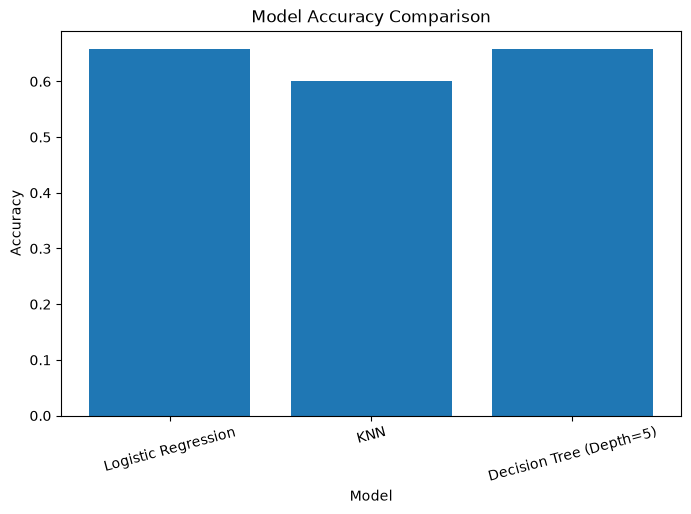

In [127]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)
plt.savefig("../visuals/Model_Accuracy_Comparison.png", bbox_inches="tight")
plt.show()

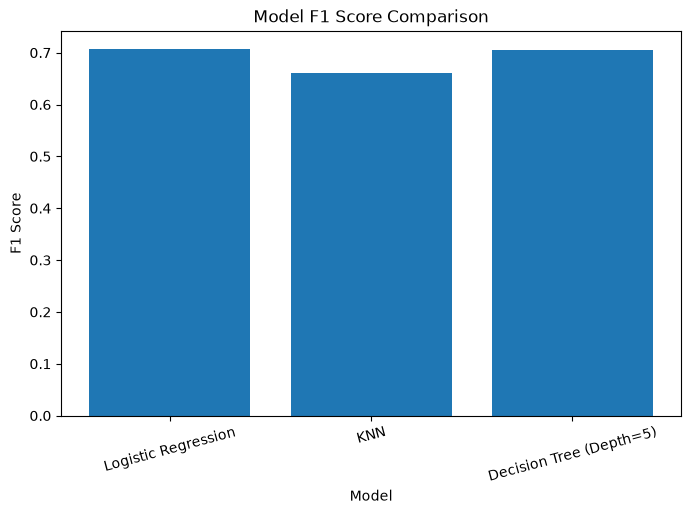

In [128]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["F1 Score"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model F1 Score Comparison")

plt.xticks(rotation=15)
plt.savefig("../visuals/Model_F1_Score_Comparison.png", bbox_inches="tight")
plt.show()

In [129]:
model_results.sort_values(
    "F1 Score",
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.658,0.698,0.717,0.707
2,Decision Tree (Depth=5),0.658,0.699,0.712,0.706
1,KNN,0.601,0.647,0.674,0.660


In [130]:
best_model_name = model_results.loc[
    model_results["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [131]:
best_model_metrics = model_results[
    model_results["Model"] == best_model_name
]

best_model_metrics.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.658,0.698,0.717,0.707


In [132]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model_depth.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Frequency,0.651995
2,Monetary,0.178356
0,Recency,0.169648


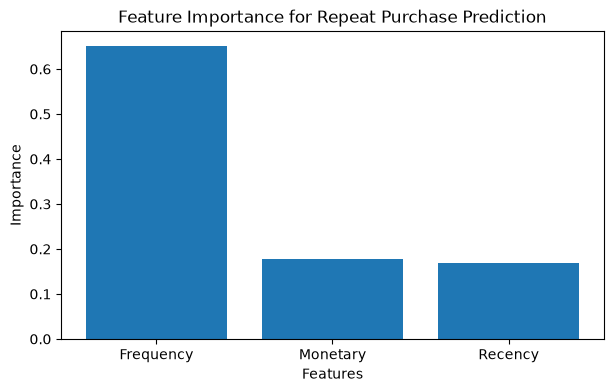

In [133]:
plt.figure(figsize=(7, 4))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance for Repeat Purchase Prediction")
plt.savefig("../visuals/Feature_Importance_for_Repeat_Purchase_Prediction.png", bbox_inches="tight")
plt.show()

In [134]:
print("FINAL MODEL RESULTS")
print("-" * 30)

print(model_results.round(3))

print("\nBest model based on F1 Score:")
print(best_model_name)

FINAL MODEL RESULTS
------------------------------
                     Model  Accuracy  Precision  Recall  F1 Score
0      Logistic Regression     0.658      0.698   0.717     0.707
1                      KNN     0.601      0.647   0.674     0.660
2  Decision Tree (Depth=5)     0.658      0.699   0.712     0.706

Best model based on F1 Score:
Logistic Regression


In [135]:
segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk Customers,1047,242.98,1.66,593.54
Loyal High-Value Customers,56,14.91,47.02,28896.42
Regular Customers,3204,43.03,4.46,1710.65
VIP Customers,5,5.60,113.60,215535.00


In [136]:
customer_segment_data = rfm[
    ["Customer ID", "Segment", "Monetary"]
].copy()

customer_segment_data.head()

,Customer ID,Segment,Monetary
0,12346.0,At-Risk Customers,372.86
1,12347.0,Regular Customers,1323.32
2,12348.0,Regular Customers,222.16
3,12349.0,Regular Customers,2671.14
4,12351.0,Regular Customers,300.93


In [137]:
segment_revenue = customer_segment_data.groupby(
    "Segment"
)["Monetary"].sum().sort_values(
    ascending=False
)

segment_revenue

Segment
Regular Customers             5480922.697
Loyal High-Value Customers    1618199.333
VIP Customers                 1077675.000
At-Risk Customers              621436.714
Name: Monetary, dtype: float64

In [138]:
segment_revenue_percentage = (
    segment_revenue
    / segment_revenue.sum()
    * 100
).round(2)

segment_revenue_percentage

Segment
Regular Customers             62.30
Loyal High-Value Customers    18.39
VIP Customers                 12.25
At-Risk Customers              7.06
Name: Monetary, dtype: float64

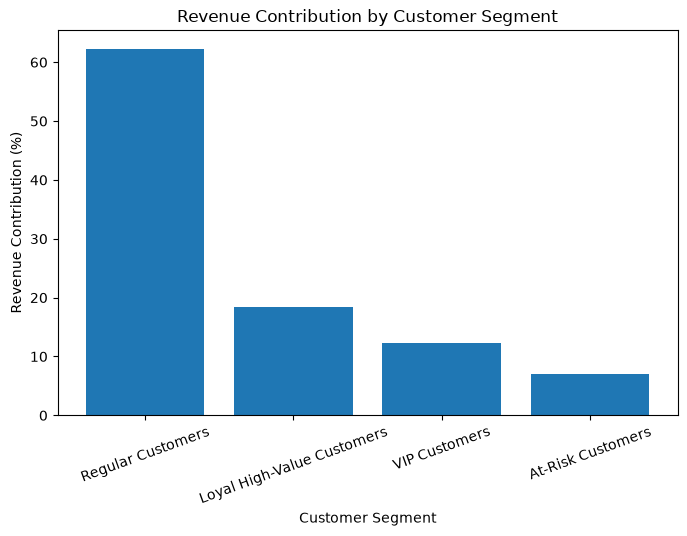

In [139]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_revenue_percentage.index,
    segment_revenue_percentage.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")
plt.title("Revenue Contribution by Customer Segment")

plt.xticks(rotation=20)
plt.savefig("../visuals/Revenue_Contribution_by_Customer_Segment.png", bbox_inches="tight")

plt.show()

In [140]:
business_insights = pd.DataFrame({
    "Customers": segment_summary["Customers"],
    "Avg Recency": segment_summary["Avg_Recency"],
    "Avg Frequency": segment_summary["Avg_Frequency"],
    "Avg Monetary": segment_summary["Avg_Monetary"],
    "Total Revenue": segment_revenue
})

business_insights.round(2)

,Customers,Avg Recency,Avg Frequency,Avg Monetary,Total Revenue
Segment,,,,,
At-Risk Customers,1047,242.98,1.66,593.54,621436.71
Loyal High-Value Customers,56,14.91,47.02,28896.42,1618199.33
Regular Customers,3204,43.03,4.46,1710.65,5480922.70
VIP Customers,5,5.60,113.60,215535.00,1077675.00


In [141]:
segment_revenue_percentage.sort_values(
    ascending=False
)

Segment
Regular Customers             62.30
Loyal High-Value Customers    18.39
VIP Customers                 12.25
At-Risk Customers              7.06
Name: Monetary, dtype: float64

In [142]:
highest_value_segment = segment_revenue.idxmax()

print("Highest Revenue Segment:")
print(highest_value_segment)

Highest Revenue Segment:
Regular Customers


In [143]:
largest_segment = segment_summary["Customers"].idxmax()

print("Largest Customer Segment:")
print(largest_segment)

Largest Customer Segment:
Regular Customers


In [144]:
recommendations = {
    "VIP Customers": "Provide exclusive rewards and personalized offers to retain these highly valuable customers.",
    
    "Loyal High-Value Customers": "Use loyalty programs, cross-selling, and premium offers to increase customer lifetime value.",
    
    "Regular Customers": "Encourage repeat purchases using personalized recommendations and targeted promotions.",
    
    "At-Risk Customers": "Launch win-back campaigns, discount offers, and reminder emails to reactivate inactive customers."
}

recommendations

{'VIP Customers': 'Provide exclusive rewards and personalized offers to retain these highly valuable customers.',
 'Loyal High-Value Customers': 'Use loyalty programs, cross-selling, and premium offers to increase customer lifetime value.',
 'Regular Customers': 'Encourage repeat purchases using personalized recommendations and targeted promotions.',
 'At-Risk Customers': 'Launch win-back campaigns, discount offers, and reminder emails to reactivate inactive customers.'}

In [145]:
recommendation_table = pd.DataFrame(
    list(recommendations.items()),
    columns=["Customer Segment", "Recommended Action"]
)

recommendation_table

,Customer Segment,Recommended Action
0,VIP Customers,Provide exclusive rewards and personalized off...
1,Loyal High-Value Customers,"Use loyalty programs, cross-selling, and premi..."
2,Regular Customers,Encourage repeat purchases using personalized ...
3,At-Risk Customers,"Launch win-back campaigns, discount offers, an..."


In [146]:
print("PROJECT INSIGHTS")
print("-" * 40)

print("Best Predictive Model: Logistic Regression")
print("Accuracy:", round(log_accuracy * 100, 2), "%")
print("F1 Score:", round(
    f1_score(y_test, y_pred_log) * 100, 2
), "%")

print("\nLargest Customer Segment:")
print(largest_segment)

print("\nHighest Revenue Segment:")
print(highest_value_segment)

print("\nCustomer Segmentation: 4 segments created")

PROJECT INSIGHTS
----------------------------------------
Best Predictive Model: Logistic Regression
Accuracy: 65.83 %
F1 Score: 70.72 %

Largest Customer Segment:
Regular Customers

Highest Revenue Segment:
Regular Customers

Customer Segmentation: 4 segments created


In [147]:
import joblib

joblib.dump(
    log_model,
    "logistic_regression_model.pkl"
)

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


In [148]:
joblib.dump(
    scaler_ml,
    "scaler_ml.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [149]:
feature_names = [
    "Recency",
    "Frequency",
    "Monetary"
]

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!


In [150]:
import os

print(os.getcwd())

c:\Users\HIMANSHI\AI_Customer_Retention_Platform\notebooks


In [151]:
import shutil
import os

files = [
    "logistic_regression_model.pkl",
    "scaler_ml.pkl",
    "feature_names.pkl"
]

for file in files:
    source = file
    destination = os.path.join("..", "models", file)
    shutil.move(source, destination)

print("All model files moved successfully!")

All model files moved successfully!
